# **Section 4: Logistic Regression Classification**

In this notebook, I will train and evaluate Logistic Regression models. I will start with a baseline model using default parameters, and will then tune the regularization parameter (C) using a cross-validated grid search.

## **1. Importing the Data**

Let's import the training, validation, and test data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")

### **1.1 Load Features**

In [2]:
# Load features and labels
cnv_data = pd.read_csv('cnvs_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = cnv_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (221, 7197)
Label shape: (221, 1)
Categories: [0 1]


### **1.2 Split Data into Train, Validation, and Test Sets**

In [3]:
# First split: 70% train+val, 30% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 70% train (from remaining), 30% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (107, 7197)
Validation set shape: (47, 7197)
Test set shape: (67, 7197)


## **2. Basic Logistic Regression**

Let's start with a basic logistic regression model using default parameters (C=1.0). I chose to use a lasso regression (penalty=l1) since I have a model with many features and do not necessarily expect all of them to be informative. Lasso regression sets some of the features to 0 and thus performs feature selection, which is of interest for our problem. 

In [4]:
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=4, penalty="l1", solver="liblinear")
)

# Train the model
print("Training Logistic Regression with C=1.0...")
logreg.fit(X_train, y_train)
print("Logistic Regression model trained successfully")

Training Logistic Regression with C=1.0...
Logistic Regression model trained successfully


### **2.1 Evaluate Baseline Model**

In [5]:
# Evaluate on training, validation, and test sets
accuracy_train = logreg.score(X_train, y_train)
accuracy_val = logreg.score(X_val, y_val)
accuracy_test = logreg.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy validation set: {accuracy_val:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy validation set: 0.8511
Accuracy test set: 0.9104


### **2.2 Classification Report and Confusion Matrix**

In [6]:
# Get predictions
y_test_pred = logreg.predict(X_test)

# Classification report
print("Classification Report (Baseline Logistic Regression):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline Logistic Regression):
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        31
           1       1.00      0.83      0.91        36

    accuracy                           0.91        67
   macro avg       0.92      0.92      0.91        67
weighted avg       0.92      0.91      0.91        67



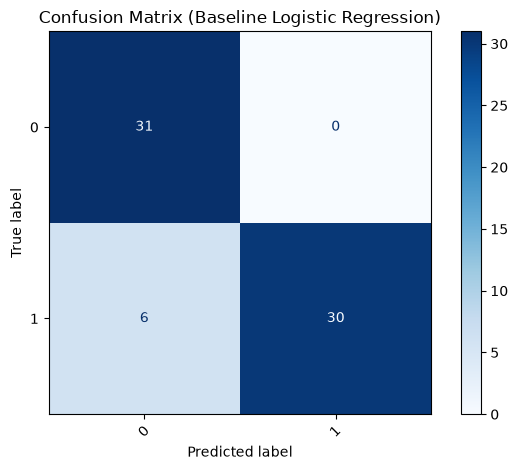

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (Baseline Logistic Regression)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing Regularization C**

Now let's use cross-validated grid search to find the optimal regularization parameter C.

### **3.1 Combine Training and Validation Sets**

In [8]:
# Combine train and validation sets
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f"Combined training set shape: {X_train_total.shape}")
print(f"Combined training set labels shape: {y_train_total.shape}")

Combined training set shape: (154, 7197)
Combined training set labels shape: (154, 1)


### **3.2 Grid Search for Optimal Hyperparameters**

In [9]:
# Create Logistic Regression pipeline
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=1, penalty="l1", solver="liblinear")
)

# Define parameter grid
param_grid = {
    'logisticregression__C': np.logspace(-1, 4, 6)
}

# Create grid search
grid_search = GridSearchCV(
    logreg_pipeline,
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
print("Performing grid search")
grid_search.fit(X_train_total, y_train_total)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Performing grid search

Best parameters: {'logisticregression__C': np.float64(1000.0)}
Best cross-validation score: 0.9477


### **3.3 Analyze Grid Search Results**

In [10]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_logisticregression__C'
]].sort_values('mean_test_score', ascending=False)

print("\nGrid Search Results:")
print(results_display)


Grid Search Results:
   mean_test_score  std_test_score  mean_train_score  std_train_score  \
4         0.947742        0.044437          1.000000          0.00000   
2         0.941505        0.051674          1.000000          0.00000   
5         0.941505        0.037703          1.000000          0.00000   
1         0.935054        0.061211          1.000000          0.00000   
3         0.934839        0.046092          1.000000          0.00000   
0         0.908817        0.085510          0.983779          0.00887   

   param_logisticregression__C  
4                       1000.0  
2                         10.0  
5                      10000.0  
1                          1.0  
3                        100.0  
0                          0.1  


### **3.4 Visualizing Training/Validation Curves**

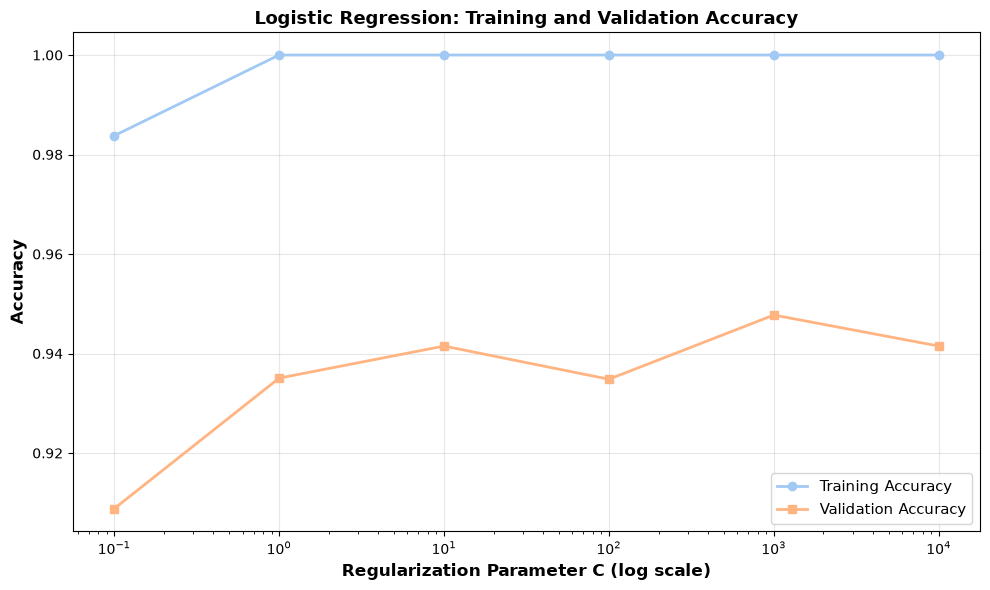

In [11]:
# Sort results by C value for plotting
cv_results_sorted = cv_results.sort_values('param_logisticregression__C')

plt.figure(figsize=(10, 6))
plt.semilogx(
    cv_results_sorted['param_logisticregression__C'],
    cv_results_sorted['mean_train_score'],
    label='Training Accuracy',
    marker='o',
    linewidth=2
)
plt.semilogx(
    cv_results_sorted['param_logisticregression__C'],
    cv_results_sorted['mean_test_score'],
    label='Validation Accuracy',
    marker='s',
    linewidth=2
)

plt.xlabel('Regularization Parameter C (log scale)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Logistic Regression: Training and Validation Accuracy', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/04_logreg_training_curves", dpi=300, bbox_inches='tight')
plt.show()

## **4. Evaluate Best Model**

In [12]:
# Evaluate best model on test set
best_logreg = grid_search.best_estimator_
accuracy_test_best = best_logreg.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best Model Test Accuracy: 0.9701
Best parameters: {'logisticregression__C': np.float64(1000.0)}
Best CV score: 0.9477


### **4.1 Classification Report**

In [13]:
# Get predictions
y_test_pred_best = best_logreg.predict(X_test)

# Classification report
print("\nClassification Report (Best Logistic Regression):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best Logistic Regression):
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        31
           1       1.00      0.94      0.97        36

    accuracy                           0.97        67
   macro avg       0.97      0.97      0.97        67
weighted avg       0.97      0.97      0.97        67



### **4.2 Confusion Matrix**

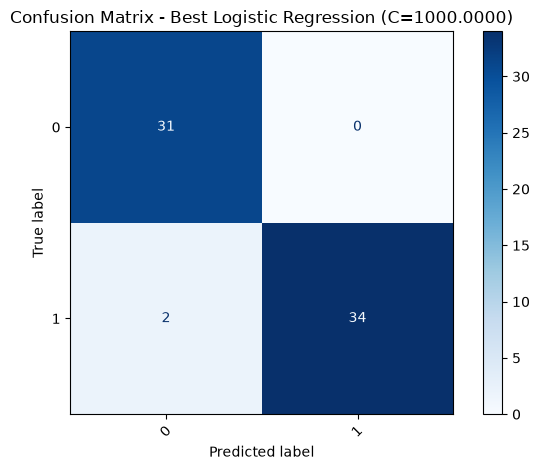

In [14]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_logreg.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_logreg.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best Logistic Regression (C={grid_search.best_params_['logisticregression__C']:.4f})")
plt.tight_layout()
plt.savefig("Figures/04_logreg_cm", dpi=300, bbox_inches='tight')
plt.show()

### **4.3 ROC Curve and AUC Score**

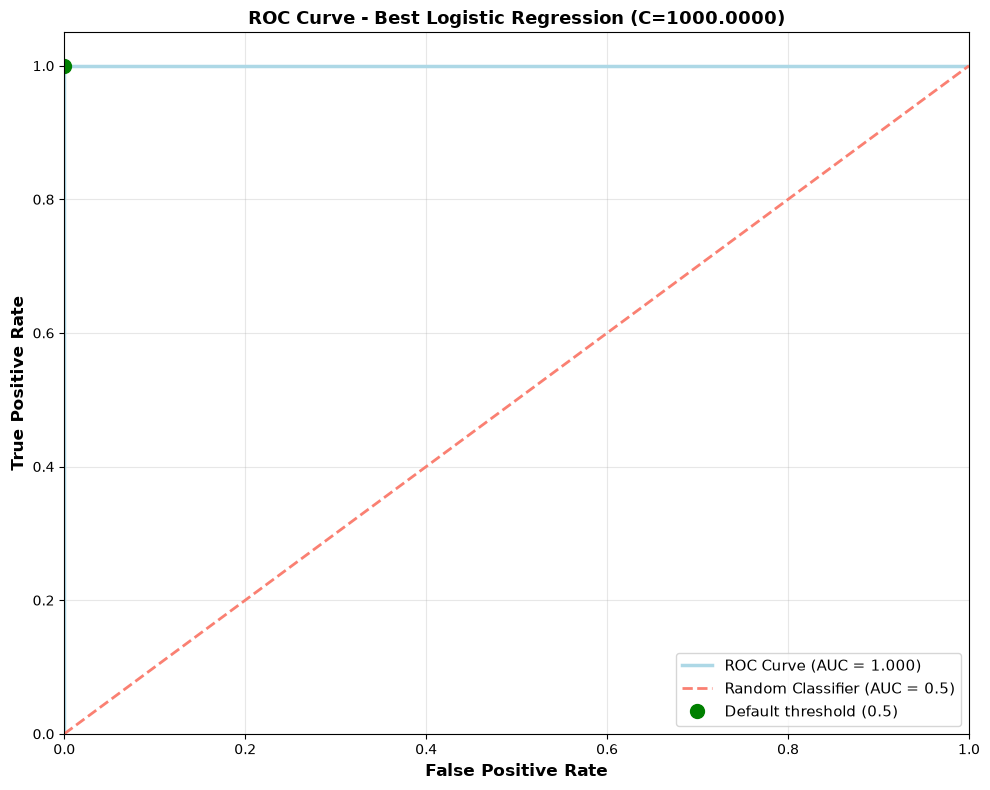


AUC Score: 1.0000
At default threshold (0.5):
  True Positive Rate (TPR): 1.000 (catch 100.0% of resistant)
  False Positive Rate (FPR): 0.000 (0.0% of susceptible misclassified)


In [15]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_logreg.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='lightblue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='salmon', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best Logistic Regression (C={grid_search.best_params_["logisticregression__C"]:.4f})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/04_logreg_ROC", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Biomarker Identification**
Let's now have a look at which features contribute the most to the model.

We will identify biomarkers (features that contribute the most to the model) using two strategies:
1. **Using Model Weights**: Identifying which features contribute the most to the model by looking at the coefficients from the logistic regression model
2. **Permutation Importance**: Identifying which features are important for the model based on performance drop when the features are permuted

### **5.1 Get Feature Names**

In [16]:
cnv_names = cnv_data.columns.values

### **5.2 Feature importance using model weights**


In [17]:
# Extract coefficients from the best model
coefficients = best_logreg.named_steps['logisticregression'].coef_[0]

# Create dataframe with feature names and coefficients
coef_df = pd.DataFrame({
    'feature': cnv_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print(f"\nTop 20 Biomarkers according to model weights:")
print(coef_df.head(20)[['feature', 'coefficient', 'abs_coefficient']].to_string(index=False))

# Separate into resistance-associated (positive) and susceptibility-associated (negative)
resistance_biomarkers = coef_df[coef_df['coefficient'] > 0].head(10)
susceptibility_biomarkers = coef_df[coef_df['coefficient'] < 0].head(10)

print(f"\n\nTop 10 Resistance-Associated Biomarkers (positive coefficients):")
print(resistance_biomarkers[['feature', 'coefficient']].to_string(index=False))

print(f"\n\nTop 10 Susceptibility-Associated Biomarkers (negative coefficients):")
print(susceptibility_biomarkers[['feature', 'coefficient']].to_string(index=False))


Top 20 Biomarkers according to model weights:
                                                           feature  coefficient  abs_coefficient
                     cnv_depth__IBNLCO_05717__mipA__gene__promoter     0.487098         0.487098
                       cnv_depth__IBNLCO_00393__IBNLCO_00393__gene     0.427416         0.427416
             cnv_depth__IBNLCO_05223__IBNLCO_05223__gene__promoter    -0.399850         0.399850
     cnv_depth__IBNLCO_03972__Succinyl-CoA:coenzyme__CDS__promoter     0.390152         0.390152
             cnv_depth__IBNLCO_00442__IBNLCO_00442__gene__promoter     0.368015         0.368015
                      cnv_depth__IBNLCO_04983__Type__CDS__promoter    -0.366731         0.366731
        cnv_depth__IBNLCO_05777__Ferredoxin--NAD(+)__CDS__promoter     0.359758         0.359758
                       cnv_depth__IBNLCO_04222__IBNLCO_04222__gene    -0.343770         0.343770
cnv_depth__IBNLCO_04972__N-acetylmuramoyl-L-alanine__CDS__promoter    -0.322048 

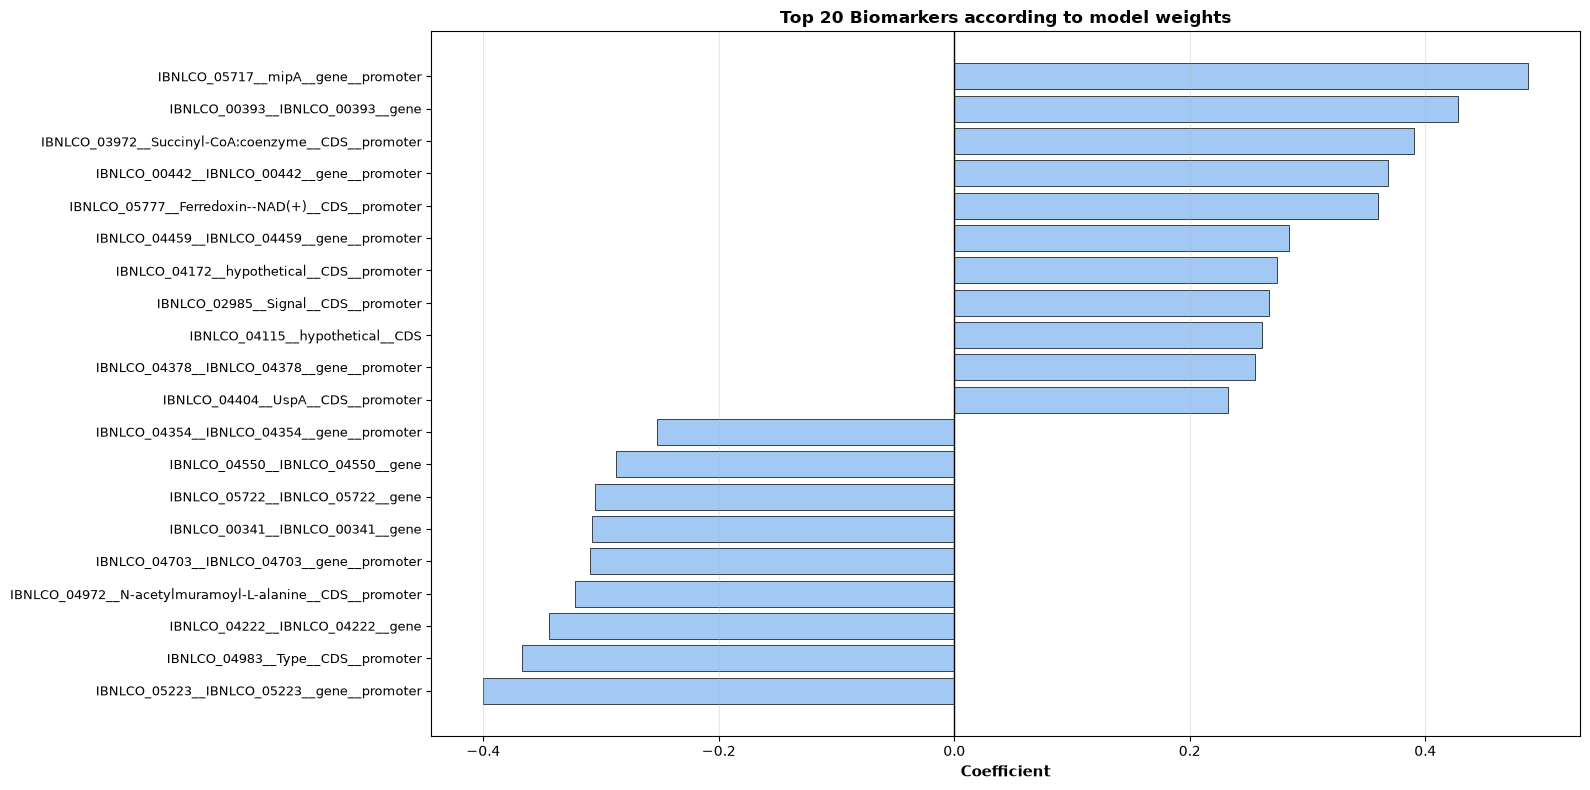

In [29]:
# Visualize top biomarkers by model weights
fig, axes = plt.subplots(1, 1, figsize=(16, 8))

# Top 20 features by absolute coefficient
ax = axes
top_20 = coef_df.head(20).sort_values("abs_coefficient")
top_20 = top_20.sort_values("coefficient")
ax.barh(range(len(top_20)), top_20['coefficient'], edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels([f.replace('cnv_depth__', '') for f in top_20['feature']], fontsize=9)
ax.set_xlabel('Coefficient', fontweight='bold', fontsize=11)
ax.set_title('Top 20 Biomarkers according to model weights', fontweight='bold', fontsize=12)
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/04_logreg_biomarkers_weights.png', dpi=300, bbox_inches='tight')
plt.show()

### **5.3 Feature Permutation Importance**

We will now assess feature importance by evaluating how much the model's performance drops when each feature is randomly shuffled.

In [19]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on test set
perm_importance = permutation_importance(
    best_logreg, X_test, y_test,
    n_repeats=10,
    random_state=1,
)

# Create dataframe with permutation importance results
perm_df = pd.DataFrame({
    'feature': cnv_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
})

# Sort by importance
perm_df = perm_df.sort_values('importance', ascending=False)

print(f"\nTop 20 Biomarkers by Permutation Importance:")
print(perm_df.head(20)[['feature', 'importance', 'std']].to_string(index=False))


Top 20 Biomarkers by Permutation Importance:
                                                       feature  importance      std
cnv_depth__IBNLCO_05664__gnl|Bakta|IBNLCO_05664__CDS__promoter    0.014925 0.000000
                 cnv_depth__IBNLCO_05717__mipA__gene__promoter    0.014925 0.011561
                   cnv_depth__IBNLCO_05682__SAF__CDS__promoter    0.013433 0.004478
cnv_depth__IBNLCO_01009__gnl|Bakta|IBNLCO_01009__CDS__promoter    0.013433 0.004478
                cnv_depth__IBNLCO_00951__CHASE2__CDS__promoter    0.011940 0.005970
           cnv_depth__IBNLCO_01372__DNA-binding__CDS__promoter    0.011940 0.005970
                  cnv_depth__IBNLCO_02632__Urea__CDS__promoter    0.011940 0.005970
                   cnv_depth__IBNLCO_02269__IBNLCO_02269__gene    0.011940 0.005970
         cnv_depth__IBNLCO_04115__IBNLCO_04115__gene__promoter    0.010448 0.006840
      cnv_depth__IBNLCO_04534__Dibenzothiophene__CDS__promoter    0.010448 0.006840
        cnv_depth__IBNLCO_0466

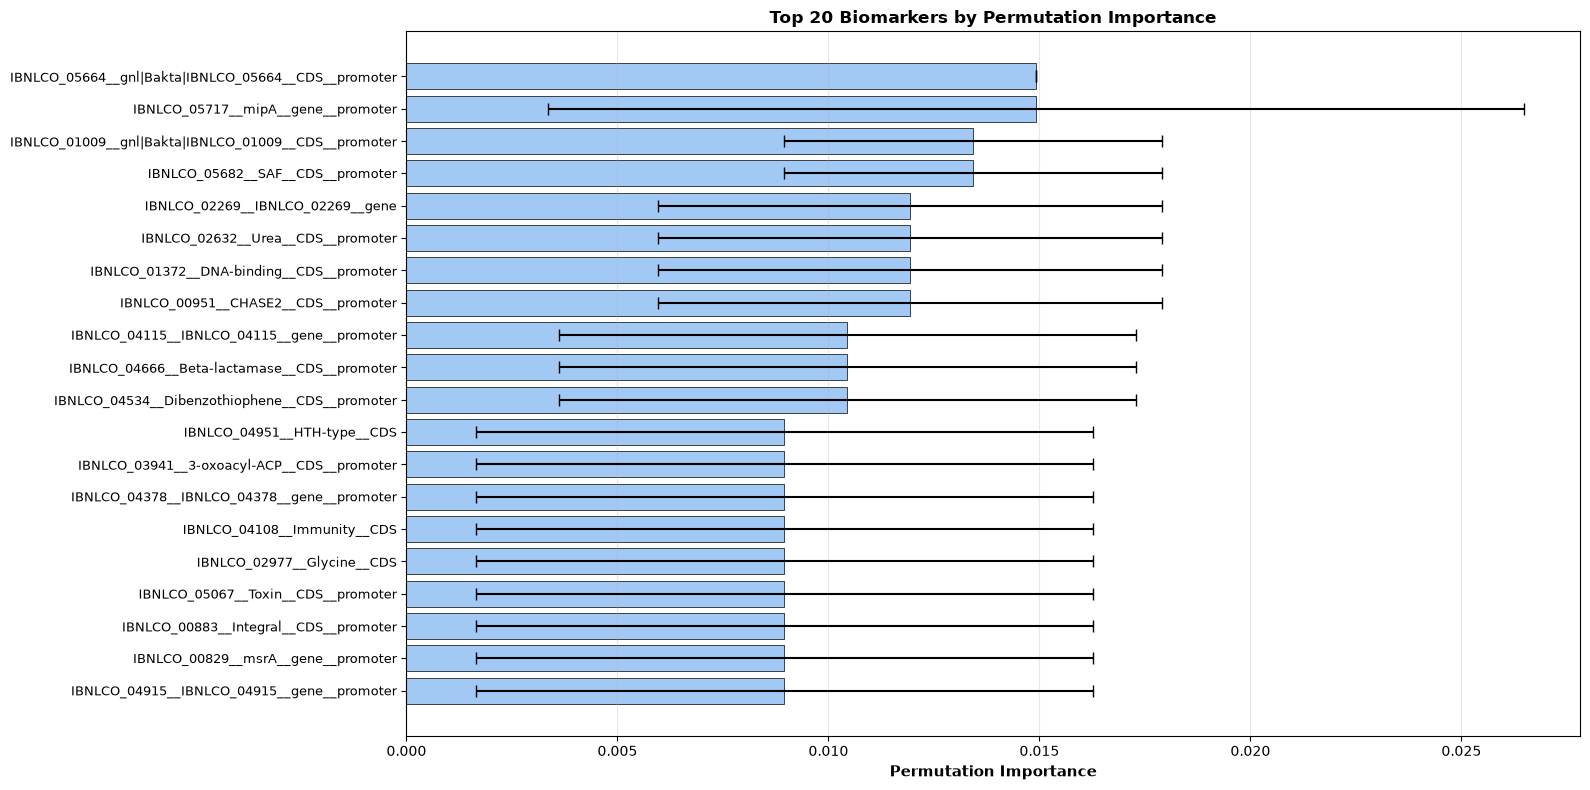

In [28]:
# Visualize permutation importance
fig, axes = plt.subplots(1, 1, figsize=(16, 8))

# Top 20 features by permutation importance
ax = axes
top_20_perm = perm_df.head(20).sort_values('importance')
ax.barh(range(len(top_20_perm)), top_20_perm['importance'], 
        xerr=top_20_perm['std'], edgecolor='black', linewidth=0.5, capsize=4)
ax.set_yticks(range(len(top_20_perm)))
ax.set_yticklabels([f.replace('cnv_depth__', '') for f in top_20_perm['feature']], fontsize=9)
ax.set_xlabel('Permutation Importance', fontweight='bold', fontsize=11)
ax.set_title('Top 20 Biomarkers by Permutation Importance', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/04_logreg_biomarkers_perm.png', dpi=300, bbox_inches='tight')
plt.show()

### **5.4 Features in common with the two methods**

In [21]:
# Select top 20 from each method
coef_features = coef_df.head(20)[['feature', 'coefficient']].copy()
coef_features['source'] = 'model_weight'

perm_features = perm_df.head(20)[['feature', 'importance']].copy()
perm_features['source'] = 'permutation_importance'

# Combine
combined = pd.concat([coef_features, perm_features], ignore_index=True)

# Normalize each metric for comparison and create a new column
combined['model_weight_norm'] = (combined['coefficient'].abs() / combined['coefficient'].abs().max())
combined['importance_norm'] = (combined['importance'] / combined['importance'].max())

# Merge duplicates biomarkers and keep sources
combined_summary = (combined.groupby('feature').agg({
        'source': list, # combine the sources into a list for each duplicated feature
        'model_weight_norm': 'max', # keep the max value (if a feature is duplicated, one of its value for model_weight will be NaN. drop it)
        'importance_norm': 'max' # same as above
    })
    .reset_index()
)

print(combined_summary["feature"])

0           cnv_depth__IBNLCO_00341__IBNLCO_00341__gene
1           cnv_depth__IBNLCO_00393__IBNLCO_00393__gene
2     cnv_depth__IBNLCO_00442__IBNLCO_00442__gene__p...
3         cnv_depth__IBNLCO_00829__msrA__gene__promoter
4      cnv_depth__IBNLCO_00883__Integral__CDS__promoter
5        cnv_depth__IBNLCO_00951__CHASE2__CDS__promoter
6     cnv_depth__IBNLCO_01009__gnl|Bakta|IBNLCO_0100...
7     cnv_depth__IBNLCO_01372__DNA-binding__CDS__pro...
8           cnv_depth__IBNLCO_02269__IBNLCO_02269__gene
9          cnv_depth__IBNLCO_02632__Urea__CDS__promoter
10                cnv_depth__IBNLCO_02977__Glycine__CDS
11       cnv_depth__IBNLCO_02985__Signal__CDS__promoter
12    cnv_depth__IBNLCO_03941__3-oxoacyl-ACP__CDS__p...
13    cnv_depth__IBNLCO_03972__Succinyl-CoA:coenzyme...
14               cnv_depth__IBNLCO_04108__Immunity__CDS
15    cnv_depth__IBNLCO_04115__IBNLCO_04115__gene__p...
16           cnv_depth__IBNLCO_04115__hypothetical__CDS
17    cnv_depth__IBNLCO_04172__hypothetical__CDS

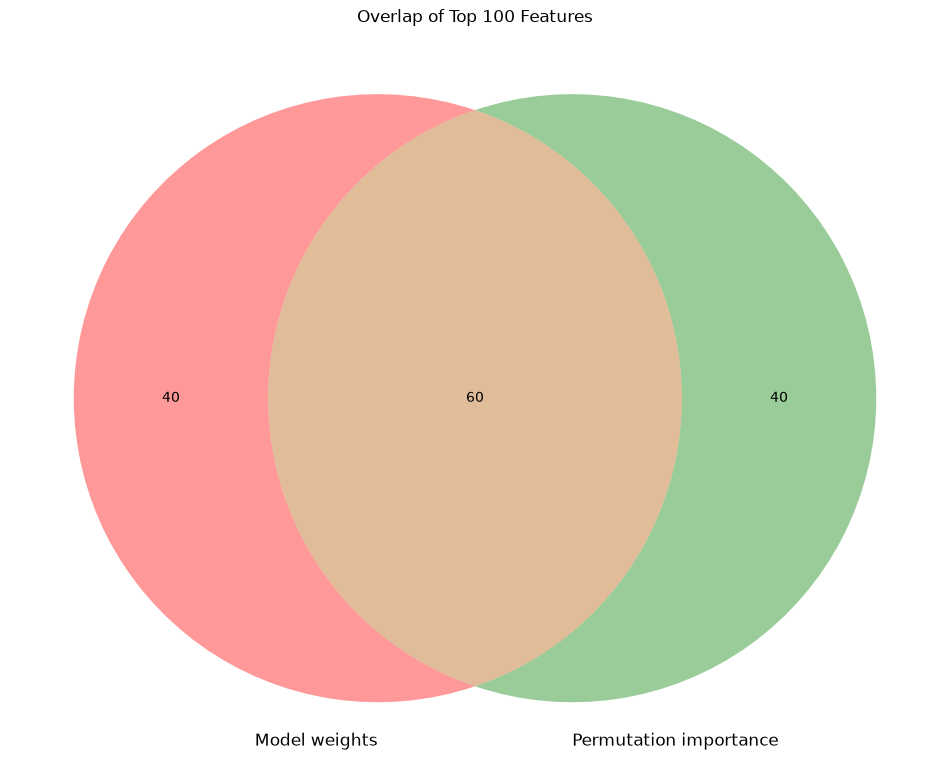

In [27]:
# venn diagram
coef_set = set(coef_df.head(100)["feature"])
perm_set = set(perm_df.head(100)["feature"])

from matplotlib_venn import venn2

plt.figure(figsize=(12,12))

venn2(
    [coef_set, perm_set],
    set_labels=("Model weights", "Permutation importance")
)

plt.title("Overlap of Top 100 Features")
plt.savefig("Figures/04_logreg_venn_biomarkers", dpi=300, bbox_inches='tight')
plt.show()

### **5.5. Save Biomarker results**

In [22]:
# Save biomarker results to CSV files
coef_df.to_csv('biomarkers_model_weights.csv', index=False)
perm_df.to_csv('biomarkers_permutation_importance.csv', index=False)

## **6. Save model results**

In [23]:
import csv
import os

# Store results
results = {
    'model': 'Logistic Regression',
    'hyperparameters': f"C={grid_search.best_params_['logisticregression__C']:.4f}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: Logistic Regression
  Hyperparameters: C=1000.0000
  Test Accuracy: 0.9701
  CV Score: 0.9477
